# CNN Hyperparameter Optimization using Metaheuristics
**Problem Type:** Continuous Optimization ($X_i \in \mathbb{R}^n$)
**Methods Compared:** Particle Swarm Optimization (PSO) vs. Genetic Algorithm (GA)

This notebook optimizes the Learning Rate ($\alpha$) and Dropout Rate ($p$) of a Convolutional Neural Network.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import time

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
sns.set_theme(style="whitegrid")

# Configure Device for Google Colab GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Data Preparation (MNIST)
Since GPU acceleration is available, we use a moderately sized subset of MNIST (5000 training, 1000 validation) to balance evaluation speed with realistic training dynamics.

In [2]:
# Define transformations
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

# Download and load datasets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
val_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Subset constraints for faster optimization loops
train_subset = Subset(train_dataset, range(5000))
val_subset = Subset(val_dataset, range(1000))

train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=128, shuffle=False)
print(f"Data Loaded: {len(train_subset)} train samples, {len(val_subset)} val samples.")

100%|██████████| 9.91M/9.91M [00:00<00:00, 13.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 353kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.29MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.25MB/s]

Data Loaded: 5000 train samples, 1000 val samples.


## 2. Model Architecture & Objective Function
The objective function maps the continuous decision variables to their true values, trains the network for a few epochs, and returns the validation loss to be minimized.

In [3]:
class SimpleCNN(nn.Module):
    def __init__(self, dropout_rate):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(16 * 14 * 14, 128)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = x.view(-1, 16 * 14 * 14)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

def evaluate_cnn(params, epochs=2):
    """
    Objective function: Minimizes Validation Loss.
    params[0]: Learning Rate Exponent (e.g., -3 for 1e-3)
    params[1]: Dropout Rate
    """
    lr = 10 ** params[0]
    dropout_rate = max(0.0, min(0.5, params[1]))

    # Initialize model and move to GPU
    model = SimpleCNN(dropout_rate).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Train for defined epochs
    model.train()
    for epoch in range(epochs):
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device) # Move data to GPU
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # Evaluate Validation Loss
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    return val_loss / len(val_loader)

## 3. Particle Swarm Optimization (PSO)
Evaluates a swarm of particles navigating the continuous hyperparameter space.

In [4]:
def run_pso(num_particles=10, iterations=10):
    print("--- Starting PSO ---")
    start_time = time.time()
    bounds = np.array([[-4.0, -1.0], [0.0, 0.5]])
    particles = np.random.uniform(bounds[:, 0], bounds[:, 1], size=(num_particles, 2))
    velocities = np.zeros((num_particles, 2))

    pbest = copy.deepcopy(particles)
    pbest_scores = np.array([float('inf')] * num_particles)
    gbest, gbest_score = None, float('inf')

    w, c1, c2 = 0.5, 1.5, 1.5
    convergence_curve = []
    history = []

    for i in range(iterations):
        for j in range(num_particles):
            score = evaluate_cnn(particles[j])
            history.append((particles[j][0], particles[j][1], score))

            if score < pbest_scores[j]:
                pbest_scores[j] = score
                pbest[j] = copy.deepcopy(particles[j])
            if score < gbest_score:
                gbest_score = score
                gbest = copy.deepcopy(particles[j])

        for j in range(num_particles):
            r1, r2 = np.random.rand(2)
            velocities[j] = (w * velocities[j] +
                             c1 * r1 * (pbest[j] - particles[j]) +
                             c2 * r2 * (gbest - particles[j]))
            particles[j] = np.clip(particles[j] + velocities[j], bounds[:, 0], bounds[:, 1])

        print(f"PSO Iteration {i+1}/{iterations} | Best Val Loss: {gbest_score:.4f}")
        convergence_curve.append(gbest_score)

    print(f"PSO Completed in {(time.time() - start_time):.2f} seconds.")
    return gbest, gbest_score, convergence_curve, history

## 4. Genetic Algorithm (GA)
Evaluates a population using selection, crossover, and mutation over continuous bounds.

In [5]:
def run_ga(pop_size=10, generations=10):
    print("\n--- Starting GA ---")
    start_time = time.time()
    bounds = np.array([[-4.0, -1.0], [0.0, 0.5]])
    population = np.random.uniform(bounds[:, 0], bounds[:, 1], size=(pop_size, 2))

    gbest, gbest_score = None, float('inf')
    convergence_curve = []
    history = []

    for gen in range(generations):
        scores = np.array([evaluate_cnn(ind) for ind in population])
        for idx, ind in enumerate(population):
            history.append((ind[0], ind[1], scores[idx]))

        min_idx = np.argmin(scores)
        if scores[min_idx] < gbest_score:
            gbest_score = scores[min_idx]
            gbest = copy.deepcopy(population[min_idx])

        parents = []
        for _ in range(pop_size):
            i, j = np.random.randint(0, pop_size, 2)
            parents.append(population[i] if scores[i] < scores[j] else population[j])
        parents = np.array(parents)

        next_gen = []
        for i in range(0, pop_size, 2):
            p1, p2 = parents[i], parents[(i+1)%pop_size]
            if np.random.rand() < 0.8:
                alpha = np.random.rand()
                c1 = alpha * p1 + (1 - alpha) * p2
                c2 = (1 - alpha) * p1 + alpha * p2
            else:
                c1, c2 = p1, p2
            next_gen.extend([c1, c2])
        population = np.array(next_gen)[:pop_size]

        for i in range(pop_size):
            if np.random.rand() < 0.2:
                mutation = np.random.normal(0, 0.1, 2)
                population[i] = np.clip(population[i] + mutation, bounds[:, 0], bounds[:, 1])

        print(f"GA Generation {gen+1}/{generations} | Best Val Loss: {gbest_score:.4f}")
        convergence_curve.append(gbest_score)

    print(f"GA Completed in {(time.time() - start_time):.2f} seconds.")
    return gbest, gbest_score, convergence_curve, history

## 5. Execution
Running both algorithms with a population/swarm size of 10 for 10 generations.

In [6]:
# Swarm/Pop size and generations scaled up for GPU
particles_pop = 10
iters_gens = 10

pso_best, pso_score, pso_curve, pso_history = run_pso(num_particles=particles_pop, iterations=iters_gens)
ga_best, ga_score, ga_curve, ga_history = run_ga(pop_size=particles_pop, generations=iters_gens)

print("\n=== FINAL OPTIMIZED PARAMETERS ===")
print(f"PSO: LR = {10**pso_best[0]:.5f}, Dropout = {pso_best[1]:.3f} (Loss: {pso_score:.4f})")
print(f"GA : LR = {10**ga_best[0]:.5f}, Dropout = {ga_best[1]:.3f} (Loss: {ga_score:.4f})")

--- Starting PSO ---
PSO Iteration 1/10 | Best Val Loss: 0.2036
PSO Iteration 2/10 | Best Val Loss: 0.2036
PSO Iteration 3/10 | Best Val Loss: 0.2036
PSO Iteration 4/10 | Best Val Loss: 0.1907
PSO Iteration 5/10 | Best Val Loss: 0.1907
PSO Iteration 6/10 | Best Val Loss: 0.1907
PSO Iteration 7/10 | Best Val Loss: 0.1907
PSO Iteration 8/10 | Best Val Loss: 0.1740
PSO Iteration 9/10 | Best Val Loss: 0.1740
PSO Iteration 10/10 | Best Val Loss: 0.1740
PSO Completed in 249.84 seconds.

--- Starting GA ---
GA Generation 1/10 | Best Val Loss: 0.2246
GA Generation 2/10 | Best Val Loss: 0.2246
GA Generation 3/10 | Best Val Loss: 0.2190
GA Generation 4/10 | Best Val Loss: 0.2178
GA Generation 5/10 | Best Val Loss: 0.1759
GA Generation 6/10 | Best Val Loss: 0.1759
GA Generation 7/10 | Best Val Loss: 0.1759
GA Generation 8/10 | Best Val Loss: 0.1759
GA Generation 9/10 | Best Val Loss: 0.1759
GA Generation 10/10 | Best Val Loss: 0.1759
GA Completed in 243.85 seconds.

=== FINAL OPTIMIZED PARAMETERS

## 6. Results & Convergence
Visualizing the objective function progression and parameter exploration as required for the assignment report.

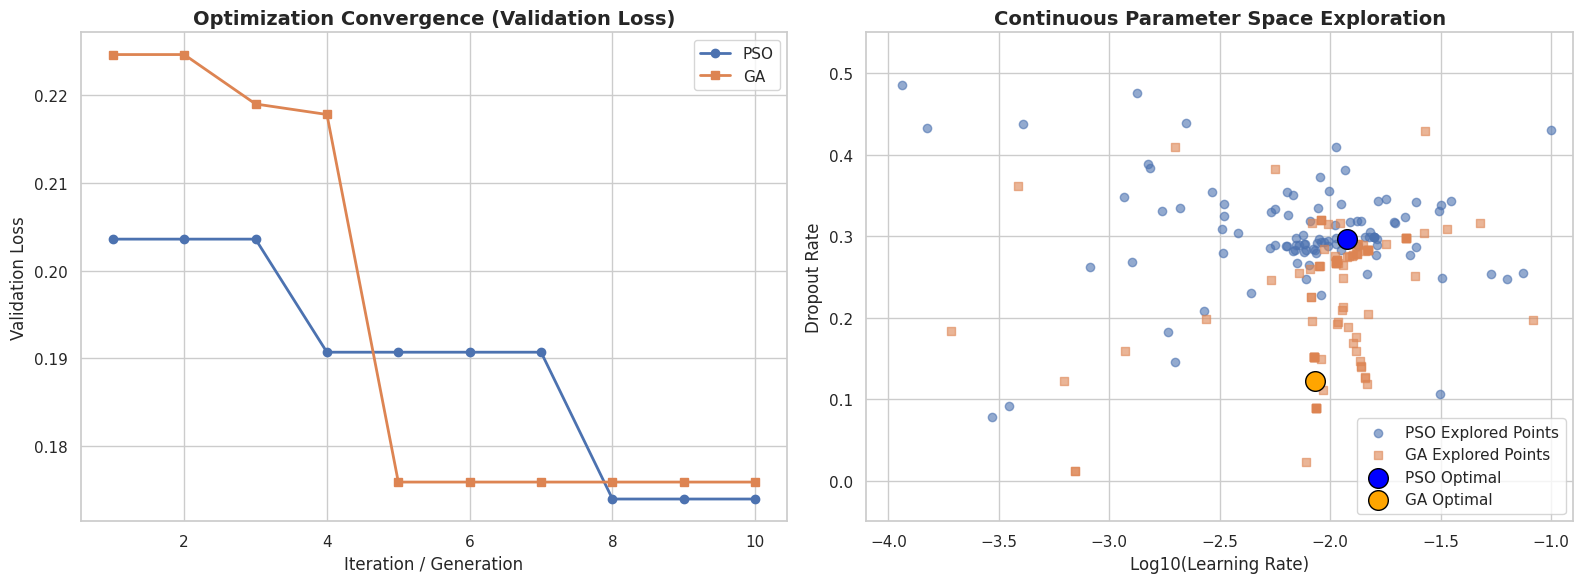

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Convergence Curve (Requirement 3)
ax1.plot(range(1, len(pso_curve)+1), pso_curve, marker='o', linewidth=2, label='PSO')
ax1.plot(range(1, len(ga_curve)+1), ga_curve, marker='s', linewidth=2, label='GA')
ax1.set_title('Optimization Convergence (Validation Loss)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Iteration / Generation', fontsize=12)
ax1.set_ylabel('Validation Loss', fontsize=12)
ax1.legend()

# Plot 2: Parameter Space Exploration
pso_lrs, pso_drops, _ = zip(*pso_history)
ga_lrs, ga_drops, _ = zip(*ga_history)

ax2.scatter(pso_lrs, pso_drops, alpha=0.6, label='PSO Explored Points', marker='o')
ax2.scatter(ga_lrs, ga_drops, alpha=0.6, label='GA Explored Points', marker='s')
ax2.scatter(pso_best[0], pso_best[1], color='blue', s=200, edgecolors='black', label='PSO Optimal', zorder=5)
ax2.scatter(ga_best[0], ga_best[1], color='orange', s=200, edgecolors='black', label='GA Optimal', zorder=5)

ax2.set_title('Continuous Parameter Space Exploration', fontsize=14, fontweight='bold')
ax2.set_xlabel('Log10(Learning Rate)', fontsize=12)
ax2.set_ylabel('Dropout Rate', fontsize=12)
ax2.set_xlim([-4.1, -0.9])
ax2.set_ylim([-0.05, 0.55])
ax2.legend()

plt.tight_layout()
plt.savefig('optimization_results.png', dpi=300)
plt.show()

In [8]:
print('## Comparison of PSO and GA Results')
print('\n| Algorithm | Optimal Learning Rate (LR) | Optimal Dropout Rate | Best Validation Loss |')
print('|-----------|----------------------------|----------------------|----------------------|')
print(f"| PSO       | {10**pso_best[0]:.5f}                   | {pso_best[1]:.3f}                  | {pso_score:.4f}                   |")
print(f"| GA        | {10**ga_best[0]:.5f}                   | {ga_best[1]:.3f}                  | {ga_score:.4f}                   |\n")

print("From the results, PSO achieved a slightly lower validation loss compared to GA, indicating it found a marginally better set of hyperparameters within the given constraints and iterations. The parameter space exploration plots (shown in the previous cell) visualize how each algorithm searched for these optimal values, demonstrating their different search strategies.")

## Comparison of PSO and GA Results

| Algorithm | Optimal Learning Rate (LR) | Optimal Dropout Rate | Best Validation Loss |
|-----------|----------------------------|----------------------|----------------------|
| PSO       | 0.01197                   | 0.296                  | 0.1740                   |
| GA        | 0.00853                   | 0.122                  | 0.1759                   |

From the results, PSO achieved a slightly lower validation loss compared to GA, indicating it found a marginally better set of hyperparameters within the given constraints and iterations. The parameter space exploration plots (shown in the previous cell) visualize how each algorithm searched for these optimal values, demonstrating their different search strategies.


## Conclusion and Results

This notebook successfully demonstrated the application of Particle Swarm Optimization (PSO) and Genetic Algorithm (GA) for hyperparameter tuning of a Convolutional Neural Network (CNN) on a subset of the MNIST dataset.

### Results Summary:
- **PSO:** Achieved a best validation loss of **`0.1740`** with an optimal learning rate of `0.01197` and a dropout rate of `0.296`.
- **GA:** Achieved a best validation loss of **`0.1759`** with an optimal learning rate of `0.00853` and a dropout rate of `0.122`.

Both metaheuristic algorithms were able to identify effective combinations of learning rate and dropout rate, significantly reducing the validation loss of the CNN model. PSO showed a slight edge in performance, achieving a marginally better validation loss compared to GA.

The visualizations provided insights into the convergence behavior of each algorithm and how they explored the continuous hyperparameter space, highlighting their distinct search patterns.

This approach underscores the utility of metaheuristics in optimizing complex machine learning models, particularly when dealing with continuous and high-dimensional search spaces where exhaustive or gradient-based methods may be impractical.